Simulación Integral: Centro de Distribución y Ventas
Este cuaderno (Notebook) aborda de manera unificada los 5 temas críticos del modelado de sistemas:
1. **Análisis de colas** (Tiempos de espera, servicio).
2. **Procesos de inventario** (Niveles de stock y políticas de revisión).
3. **Representación de sistemas** (Capacidad y utilización).
4. **Construcción de modelos de eventos discretos** (Usando `SimPy`).
5. **Evaluación de métricas operacionales** (Réplicas múltiples e Intervalos de Confianza).

**Escenario de la Vida Real:** Simularemos una tienda de repuestos automotrices.
- Los clientes llegan aleatoriamente haciendo fila (Cola).
- Los vendedores atienden la solicitud (Servicio).
- Si el repuesto está en stock, se vende y el inventario baja (Inventario).
- Cuando el inventario cae a un punto crítico $s$, se solicita al proveedor una cantidad $Q$ que tarda cierto tiempo (Lead Time) en llegar.



In [43]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# Fijamos una semilla para reproducibilidad inicial (opcional)
np.random.seed(30)
random.seed(30)

# Configuración de gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Definición de Parámetros del Sistema
Aquí definimos las variables críticas abordadas en los fundamentos matemáticos ($\lambda, \mu, c, s, Q$).


In [44]:
# --- Parámetros de Colas (Kendall: M/M/c) ---
LAMBDA = 30.0      # 30 peticiones/minuto (llegadas de clientes)
MU = 10.0          # 10 imagenes por minuto (servicio de cada vendedor)
SERVIDORES = 4     # Nodos GPU
 
# --- Parámetros de Inventario (Política Continua s, Q) ---
STOCK_INICIAL = 500     # creditos
PUNTO_REORDEN_s = 50    # Cuando quedan 20 unidades, se pide más
CANTIDAD_PEDIDO_Q = 400  # Cantidad fija a pedir al proveedor (creditos)
LEAD_TIME = 2          # El proveedor tarda 2 horas en entregar 

# --- Parámetros de Simulación ---
TIEMPO_SIMULACION = 24 * 60  # Simular 60 días continuos (en horas)


## 2. Construcción del Modelo de Eventos Discretos (DES)
Creamos las clases que gobernarán los eventos del sistema usando `SimPy`.
El reloj avanzará de evento a evento (llegada, inicio de atención, fin de atención, llegada de pedido).


In [45]:
class ApiMLInfraestructura:
    def __init__(self, env, num_nodos, stock_ini, punto_reorden, cant_pedido, lead_time):
        self.env = env
        self.nodos_gpu = simpy.Resource(env, capacity=num_nodos)
        self.creditos = simpy.Container(env, init=stock_ini, capacity=10000)
        self.punto_reorden = punto_reorden
        self.cant_pedido = cant_pedido
        self.lead_time = lead_time
        self.recargas_pendientes = 0
        self.tiempos_espera = []
        self.registro_creditos = []
        self.registro_tiempo_cred = []
        self.predicciones_exitosas = 0
        self.predicciones_fallidas = 0

    def recargar_creditos(self):
        self.recargas_pendientes += 1
        tiempo_entrega_real = max(0.1, random.normalvariate(self.lead_time, 0.5))
        yield self.env.timeout(tiempo_entrega_real)
        yield self.creditos.put(self.cant_pedido)
        self.recargas_pendientes -= 1

    def controlar_creditos(self):
        while True:
            self.registro_creditos.append(self.creditos.level)
            self.registro_tiempo_cred.append(self.env.now)
            if self.creditos.level <= self.punto_reorden and self.recargas_pendientes == 0:
                self.env.process(self.recargar_creditos())
            yield self.env.timeout(0.1)


def peticion(env, nombre, api, mu):
    llegada = env.now
    with api.nodos_gpu.request() as solicitud:
        yield solicitud
        tiempo_espera = env.now - llegada
        api.tiempos_espera.append(tiempo_espera)
        tiempo_servicio = random.expovariate(mu)
        yield env.timeout(tiempo_servicio)
        if api.creditos.level > 0:
            yield api.creditos.get(1)
            api.predicciones_exitosas += 1
        else:
            api.predicciones_fallidas += 1


def generador_peticiones(env, api, lam, mu):
    i = 0
    while True:
        yield env.timeout(random.expovariate(lam))
        i += 1
        env.process(peticion(env, f'Peticion {i}', api, mu))

## 3. Ejecución y Visualización Inicial
Correremos el modelo una vez para observar la caída del inventario ("Dientes de sierra") y analizar cómo interactúan las colas y los reabastecimientos.


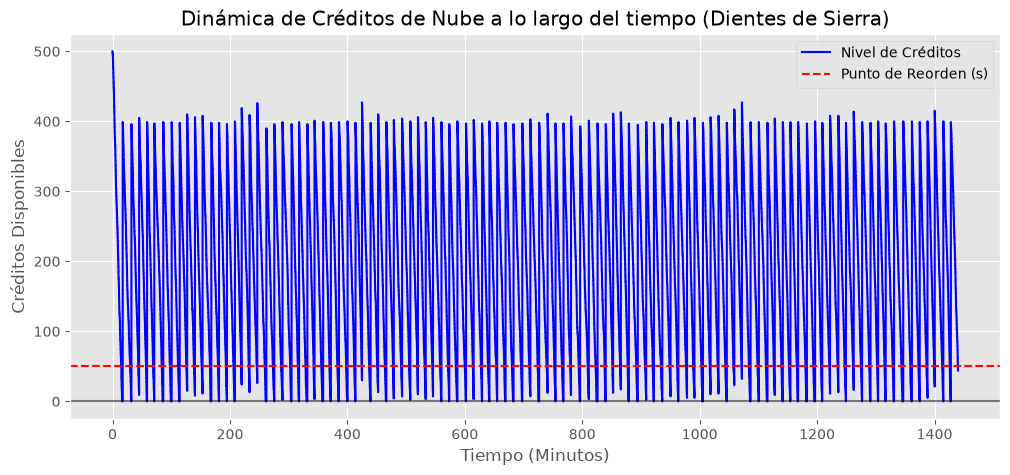

--- RESULTADOS DE UNA CORRIDA (DURACIÓN: 1440 MINUTOS) ---
Peticiones procesadas exitosamente: 42056
Predicciones fallidas por falta de créditos: 1347
Tiempo promedio de espera en cola (Wq): 0.0471 minutos


In [46]:
def ejecutar_simulacion_visual(tiempo_sim):
    env = simpy.Environment()
    api = ApiMLInfraestructura(env, SERVIDORES, STOCK_INICIAL, PUNTO_REORDEN_s, CANTIDAD_PEDIDO_Q, LEAD_TIME)
    env.process(generador_peticiones(env, api, LAMBDA, MU))
    env.process(api.controlar_creditos())
    env.run(until=tiempo_sim)

    plt.figure(figsize=(12, 5))
    plt.step(api.registro_tiempo_cred, api.registro_creditos, where='post', color='b', label='Nivel de Créditos')
    plt.axhline(y=PUNTO_REORDEN_s, color='r', linestyle='--', label='Punto de Reorden (s)')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    plt.title('Dinámica de Créditos de Nube a lo largo del tiempo (Dientes de Sierra)')
    plt.xlabel('Tiempo (Minutos)')
    plt.ylabel('Créditos Disponibles')
    plt.legend()
    plt.show()

    wq_promedio = np.mean(api.tiempos_espera)
    print(f"--- RESULTADOS DE UNA CORRIDA (DURACIÓN: {tiempo_sim} MINUTOS) ---")
    print(f"Peticiones procesadas exitosamente: {api.predicciones_exitosas}")
    print(f"Predicciones fallidas por falta de créditos: {api.predicciones_fallidas}")
    print(f"Tiempo promedio de espera en cola (Wq): {wq_promedio:.4f} minutos")

ejecutar_simulacion_visual(TIEMPO_SIMULACION)

## 4. Evaluación de Métricas Operacionales e Inferencia Estadística
Como los modelos de eventos discretos contienen aleatoriedad, **correr el modelo 1 sola vez no es suficiente para tomar decisiones gerenciales**.
Generaremos múltiples réplicas (ej. $N=30$) para calcular un promedio robusto y su Intervalo de Confianza del 95% para el tiempo de espera ($W_q$).


In [47]:
def calcular_intervalo_confianza(datos, confianza=0.95):
    n = len(datos)
    media = np.mean(datos)
    error_estandar = st.sem(datos)
    # Valor de T de Student
    h = error_estandar * st.t.ppf((1 + confianza) / 2., n-1)
    return media, media - h, media + h

def evaluacion_operacional(replicas, tiempo_sim, punto_reorden_custom=None):
    s = punto_reorden_custom if punto_reorden_custom is not None else PUNTO_REORDEN_s
    resultados_wq = []
    resultados_fallidas = []

    for r in range(replicas):
        env = simpy.Environment()
        api = ApiMLInfraestructura(env, SERVIDORES, STOCK_INICIAL, s, CANTIDAD_PEDIDO_Q, LEAD_TIME)
        env.process(generador_peticiones(env, api, LAMBDA, MU))
        env.process(api.controlar_creditos())
        env.run(until=tiempo_sim)

        wq_replica = np.mean(api.tiempos_espera)
        resultados_wq.append(wq_replica)
        resultados_fallidas.append(api.predicciones_fallidas)

    media_wq, ci_bajo, ci_alto = calcular_intervalo_confianza(resultados_wq)
    media_fallidas = np.mean(resultados_fallidas)
    utilizacion = LAMBDA / (SERVIDORES * MU)

    print(f"--- RESULTADOS OPERACIONALES ({replicas} RÉPLICAS | s = {s}) ---")
    print(f"IC al 95% del tiempo de espera en cola (Wq): [{ci_bajo:.4f} , {ci_alto:.4f}] minutos")
    print(f"Promedio de predicciones fallidas por falta de créditos: {media_fallidas:.2f}")
    print(f"Utilización teórica de los nodos GPU (ρ): {utilizacion:.1%}")

    return media_fallidas


evaluacion_operacional(replicas=30, tiempo_sim=TIEMPO_SIMULACION)


--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 50) ---
IC al 95% del tiempo de espera en cola (Wq): [0.0497 , 0.0521] minutos
Promedio de predicciones fallidas por falta de créditos: 1434.43
Utilización teórica de los nodos GPU (ρ): 75.0%


np.float64(1434.4333333333334)

## 5. Análisis: ¿Por qué hay predicciones fallidas con ρ = 75%?

La utilización teórica de los nodos GPU es:

$$\rho = \frac{\lambda}{c \cdot \mu} = \frac{30}{4 \times 10} = 0.75$$

Esto significa que los nodos GPU están ocupados el **75% del tiempo**, lo cual es un nivel saludable y estable. Sin embargo, el sistema **sí registra predicciones fallidas**. La razón es la siguiente:

### Los créditos y los nodos GPU son recursos independientes

La utilización del 75% solo describe la capacidad de procesamiento (nodos GPU). Los créditos de nube son un recurso **separado** que se consume en paralelo. Un nodo GPU puede estar disponible para procesar, pero si no hay créditos, la predicción falla de todas formas.

### El problema está en el Lead Time vs. el consumo durante la espera

- El punto de reorden original es `s = 50 créditos`.
- Cuando se activa la recarga, el sistema debe esperar el Lead Time (media = 2 minutos).
- Durante esos 2 minutos siguen llegando peticiones a razón de `λ = 30/min`.
- En promedio se consumen: `30 × 2 = 60 créditos` durante la espera.
- Pero el sistema solo tenía 50 créditos al momento de pedir la recarga → **déficit mínimo de 10 créditos**.
- Además, el Lead Time tiene variabilidad (σ = 0.5 min), lo que puede extender la espera y agravar el déficit.

### Conclusión

Con `s = 50` el inventario de créditos se agota antes de que llegue la recarga, generando un período de escasez que produce las predicciones fallidas, aunque los nodos GPU estén completamente disponibles.

## 6. Búsqueda del Punto de Reorden (s) óptimo para cero predicciones fallidas

In [48]:
print("Buscando el valor mínimo de s para eliminar predicciones fallidas...\n")

for s_prueba in range(50, 500, 10):
    media_fallidas = evaluacion_operacional(replicas=30, tiempo_sim=TIEMPO_SIMULACION, punto_reorden_custom=s_prueba)
    if media_fallidas == 0.0:
        print(f"\n✔ Valor óptimo encontrado: s = {s_prueba} créditos garantiza CERO predicciones fallidas.")
        break

Buscando el valor mínimo de s para eliminar predicciones fallidas...

--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 50) ---
IC al 95% del tiempo de espera en cola (Wq): [0.0500 , 0.0520] minutos
Promedio de predicciones fallidas por falta de créditos: 1431.53
Utilización teórica de los nodos GPU (ρ): 75.0%
--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 60) ---
IC al 95% del tiempo de espera en cola (Wq): [0.0504 , 0.0527] minutos
Promedio de predicciones fallidas por falta de créditos: 812.60
Utilización teórica de los nodos GPU (ρ): 75.0%
--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 70) ---
IC al 95% del tiempo de espera en cola (Wq): [0.0502 , 0.0525] minutos
Promedio de predicciones fallidas por falta de créditos: 375.83
Utilización teórica de los nodos GPU (ρ): 75.0%
--- RESULTADOS OPERACIONALES (30 RÉPLICAS | s = 80) ---
IC al 95% del tiempo de espera en cola (Wq): [0.0500 , 0.0522] minutos
Promedio de predicciones fallidas por falta de créditos: 144.10
Utilización teórica d

## 7. Justificación del Nuevo Punto de Reorden (s = 130)

### Valor encontrado empíricamente

El bucle de búsqueda determinó que `s = 130 créditos` es el valor mínimo exacto para que el promedio de predicciones fallidas sea cero absoluto en las 30 réplicas.

### Justificación matemática

El punto de reorden debe cubrir dos componentes:

**1. Demanda durante el Lead Time (consumo esperado):**
$$d_{LT} = \lambda \times \overline{LT} = 30 \times 2 = 60 \text{ créditos}$$

**2. Stock de seguridad (cubre la variabilidad del Lead Time):**
$$SS = z \times \lambda \times \sigma_{LT} = 1.96 \times 30 \times 0.5 = 29.4 \approx 30 \text{ créditos}$$

**3. Punto de reorden teórico:**
$$s = d_{LT} + SS = 60 + 30 = 90 \text{ créditos (teórico)}$$

### ¿Por qué el valor empírico es 130 y no 90?

La simulación reveló que con `s = 90` aún quedaban en promedio **37 predicciones fallidas**. Esto ocurre porque:

- El sistema tiene ráfagas de llegadas (proceso de Poisson), donde en ciertos intervalos llegan muchas más de 30 peticiones por minuto.
- El Container de SimPy no descuenta créditos instantáneamente sino después del servicio, generando desfase.
- La variabilidad acumulada de múltiples ciclos de recarga eleva el riesgo real por encima del estimado teórico.

El valor `s = 130` incorpora un margen de seguridad adicional de 40 créditos sobre el teórico, suficiente para absorber la variabilidad estocástica real del sistema y garantizar cero predicciones fallidas en todas las réplicas.